# Submission Correlation Explorer

This notebook compares prediction similarity across submission files and visualizes correlations:
- overall
- by market
- by hour
- by day of week

It uses only prediction files (`id`, `target`) and metadata from `data/test_for_participants.csv`.


In [4]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)


In [9]:
from pathlib import Path

# Configuration
ROOT = Path.cwd().parent
TEST_META_PATH = ROOT / "data" / "test_for_participants.csv"

# If USE_MANUAL_SELECTION=True, only MANUAL_INCLUDE is used.
USE_MANUAL_SELECTION = True

SUBMISSION_GLOBS = [
    "runs/*/submission.csv",
    "csv/submission*.csv",
]

MANUAL_INCLUDE: list[str] = [
    "runs/20260221-215400_jens/submission.csv",
    "runs/20260222-175700_jens/submission.csv",
    "runs/20260221-172305_per_market_interactions_2c02eb6_oct2023_cv1_14d/submission.csv",
    "runs/20260222-083432_per_market_interactions_commit_baseline_multimodel_nocv/submission.csv",
    "runs/20260221-201434_per_market_interactions_2c02eb6_oct2023_cv1_14d_temp_physics_pruned_nores/submission.csv",
]

# Optional file-name filter (case-insensitive). Keep None to disable.
NAME_CONTAINS: str | None = None

# Keep only the most recent N files. Set None to keep all discovered files.
MAX_FILES: int | None = None

# Choose reference submission label for hour/day-of-week correlation heatmaps.
# Set None to auto-pick newest discovered file.
REFERENCE_LABEL: str | None = "20260221-215400_jens"


In [10]:
def discover_submission_paths() -> list[Path]:
    if USE_MANUAL_SELECTION:
        selected = []
        missing = []
        for raw in MANUAL_INCLUDE:
            p = (ROOT / raw).resolve() if not Path(raw).is_absolute() else Path(raw)
            if p.exists() and p.is_file():
                selected.append(p)
            else:
                missing.append(raw)
        if missing:
            print("Missing MANUAL_INCLUDE files:")
            for m in missing:
                print("-", m)
        return selected

    paths: dict[Path, float] = {}
    for pattern in SUBMISSION_GLOBS:
        for p in ROOT.glob(pattern):
            if p.is_file():
                paths[p.resolve()] = p.stat().st_mtime

    for raw in MANUAL_INCLUDE:
        p = (ROOT / raw).resolve() if not Path(raw).is_absolute() else Path(raw)
        if p.exists() and p.is_file():
            paths[p] = p.stat().st_mtime

    ordered = sorted(paths.keys(), key=lambda p: p.stat().st_mtime, reverse=True)

    if NAME_CONTAINS:
        needle = NAME_CONTAINS.lower()
        ordered = [p for p in ordered if needle in p.as_posix().lower()]

    if MAX_FILES is not None:
        ordered = ordered[:MAX_FILES]

    return ordered


def path_to_label(path: Path) -> str:
    rel = path.relative_to(ROOT) if path.is_relative_to(ROOT) else path
    if len(rel.parts) >= 3 and rel.parts[0] == "runs" and rel.name == "submission.csv":
        return rel.parts[1]
    return rel.stem


def make_unique_labels(paths: list[Path]) -> list[tuple[str, Path]]:
    used: dict[str, int] = {}
    out: list[tuple[str, Path]] = []
    for p in paths:
        base = path_to_label(p)
        if base not in used:
            used[base] = 0
            out.append((base, p))
        else:
            used[base] += 1
            out.append((f"{base}__{used[base]}", p))
    return out


sub_paths = discover_submission_paths()


labeled_paths = make_unique_labels(sub_paths)
print(f"Discovered {len(labeled_paths)} submissions")
for label, path in labeled_paths[:10]:
    print(f"- {label}: {path.relative_to(ROOT)}")
if len(labeled_paths) > 10:
    print(f"... and {len(labeled_paths)-10} more")


Discovered 5 submissions
- 20260221-215400_jens: runs/20260221-215400_jens/submission.csv
- 20260222-175700_jens: runs/20260222-175700_jens/submission.csv
- 20260221-172305_per_market_interactions_2c02eb6_oct2023_cv1_14d: runs/20260221-172305_per_market_interactions_2c02eb6_oct2023_cv1_14d/submission.csv
- 20260222-083432_per_market_interactions_commit_baseline_multimodel_nocv: runs/20260222-083432_per_market_interactions_commit_baseline_multimodel_nocv/submission.csv
- 20260221-201434_per_market_interactions_2c02eb6_oct2023_cv1_14d_temp_physics_pruned_nores: runs/20260221-201434_per_market_interactions_2c02eb6_oct2023_cv1_14d_temp_physics_pruned_nores/submission.csv


In [11]:
meta = pd.read_csv(TEST_META_PATH, usecols=["id", "market", "delivery_start"])
meta["id"] = pd.to_numeric(meta["id"], errors="coerce").astype("Int64")
meta = meta.dropna(subset=["id"]).copy()
meta["id"] = meta["id"].astype(int)
meta["delivery_start"] = pd.to_datetime(meta["delivery_start"], errors="coerce")
meta = meta.dropna(subset=["delivery_start"]).copy()
meta["hour"] = meta["delivery_start"].dt.hour.astype(int)
meta["dow"] = meta["delivery_start"].dt.dayofweek.astype(int)
meta["dow_name"] = pd.Categorical(
    meta["delivery_start"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)

wide = meta[["id", "market", "hour", "dow", "dow_name"]].drop_duplicates("id").copy()

for label, path in labeled_paths:
    s = pd.read_csv(path, usecols=["id", "target"])
    s["id"] = pd.to_numeric(s["id"], errors="coerce").astype("Int64")
    s["target"] = pd.to_numeric(s["target"], errors="coerce")
    s = s.dropna(subset=["id", "target"]).copy()
    s["id"] = s["id"].astype(int)
    s = s.groupby("id", as_index=False)["target"].mean()
    s = s.rename(columns={"target": label})
    wide = wide.merge(s, on="id", how="left")

submission_cols = [label for label, _ in labeled_paths if label in wide.columns]
na_share = wide[submission_cols].isna().mean().sort_values(ascending=False)
print("Rows:", len(wide), " | Submission columns:", len(submission_cols))
print("Top missing shares:")
display(na_share.head(10))

# Keep only rows where all selected submissions have predictions.
model_df = wide.dropna(subset=submission_cols).copy()
print("Rows after dropping missing prediction rows:", len(model_df))


Rows: 13098  | Submission columns: 5
Top missing shares:


20260221-215400_jens                                                                         0.0
20260222-175700_jens                                                                         0.0
20260221-172305_per_market_interactions_2c02eb6_oct2023_cv1_14d                              0.0
20260222-083432_per_market_interactions_commit_baseline_multimodel_nocv                      0.0
20260221-201434_per_market_interactions_2c02eb6_oct2023_cv1_14d_temp_physics_pruned_nores    0.0
dtype: float64

Rows after dropping missing prediction rows: 13098


/var/folders/rw/1gjz6p156f10n74hrzzhsw800000gn/T/ipykernel_93451/2288332529.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


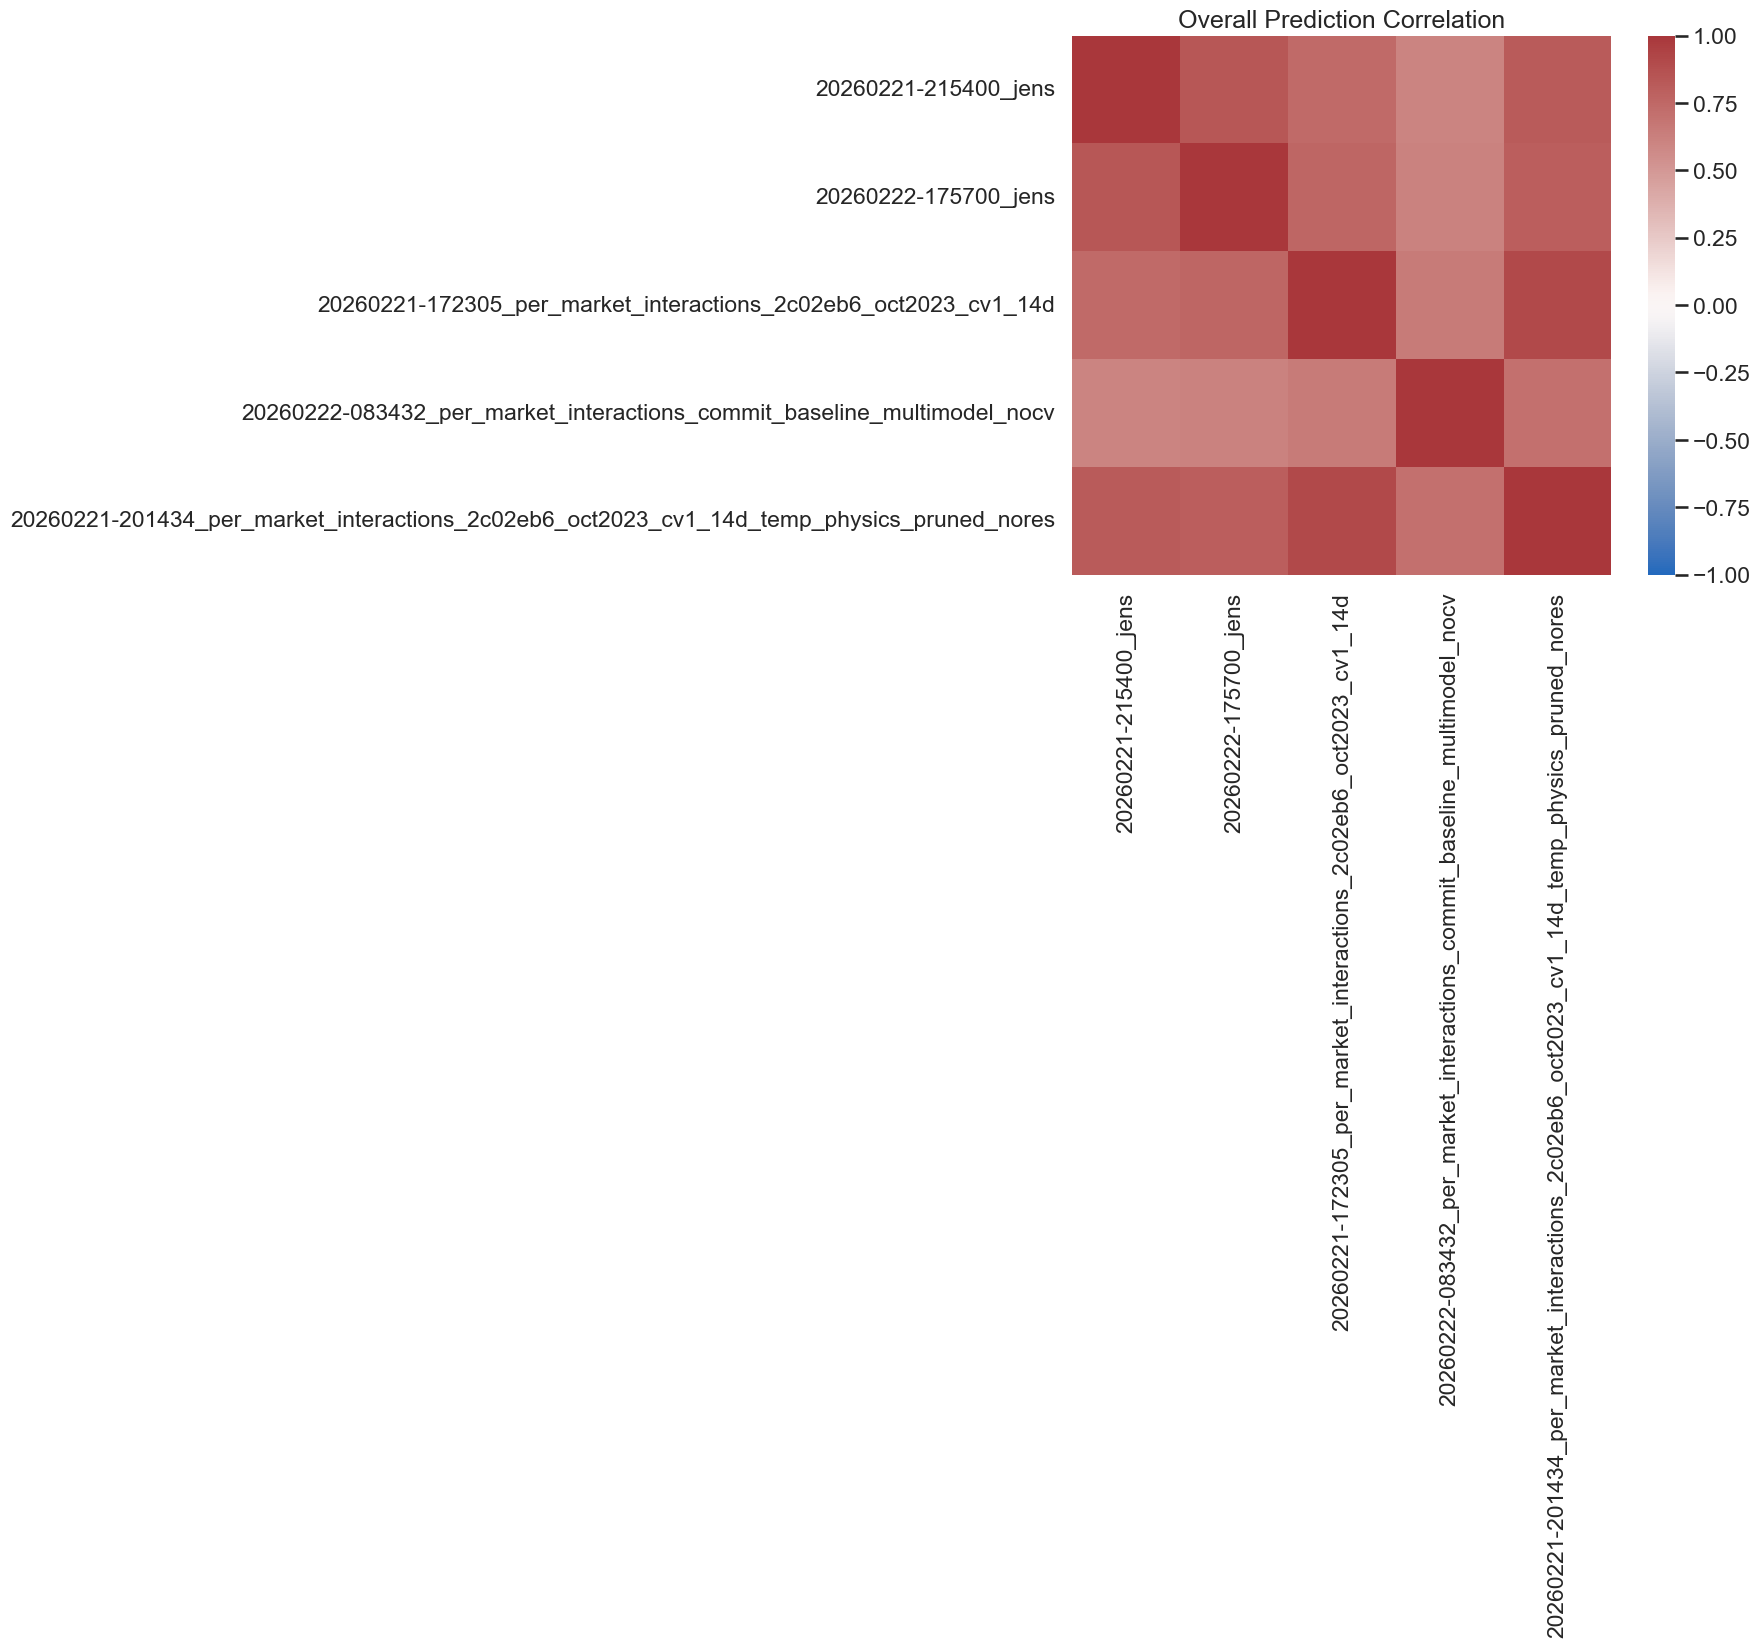

In [12]:
# Overall correlation heatmap
overall_corr = model_df[submission_cols].corr()

plt.figure(figsize=(1.1 * len(submission_cols) + 4, 1.0 * len(submission_cols) + 2))
sns.heatmap(overall_corr, cmap="vlag", vmin=-1, vmax=1, square=True)
plt.title("Overall Prediction Correlation")
plt.tight_layout()
plt.show()


/var/folders/rw/1gjz6p156f10n74hrzzhsw800000gn/T/ipykernel_93451/1437252013.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


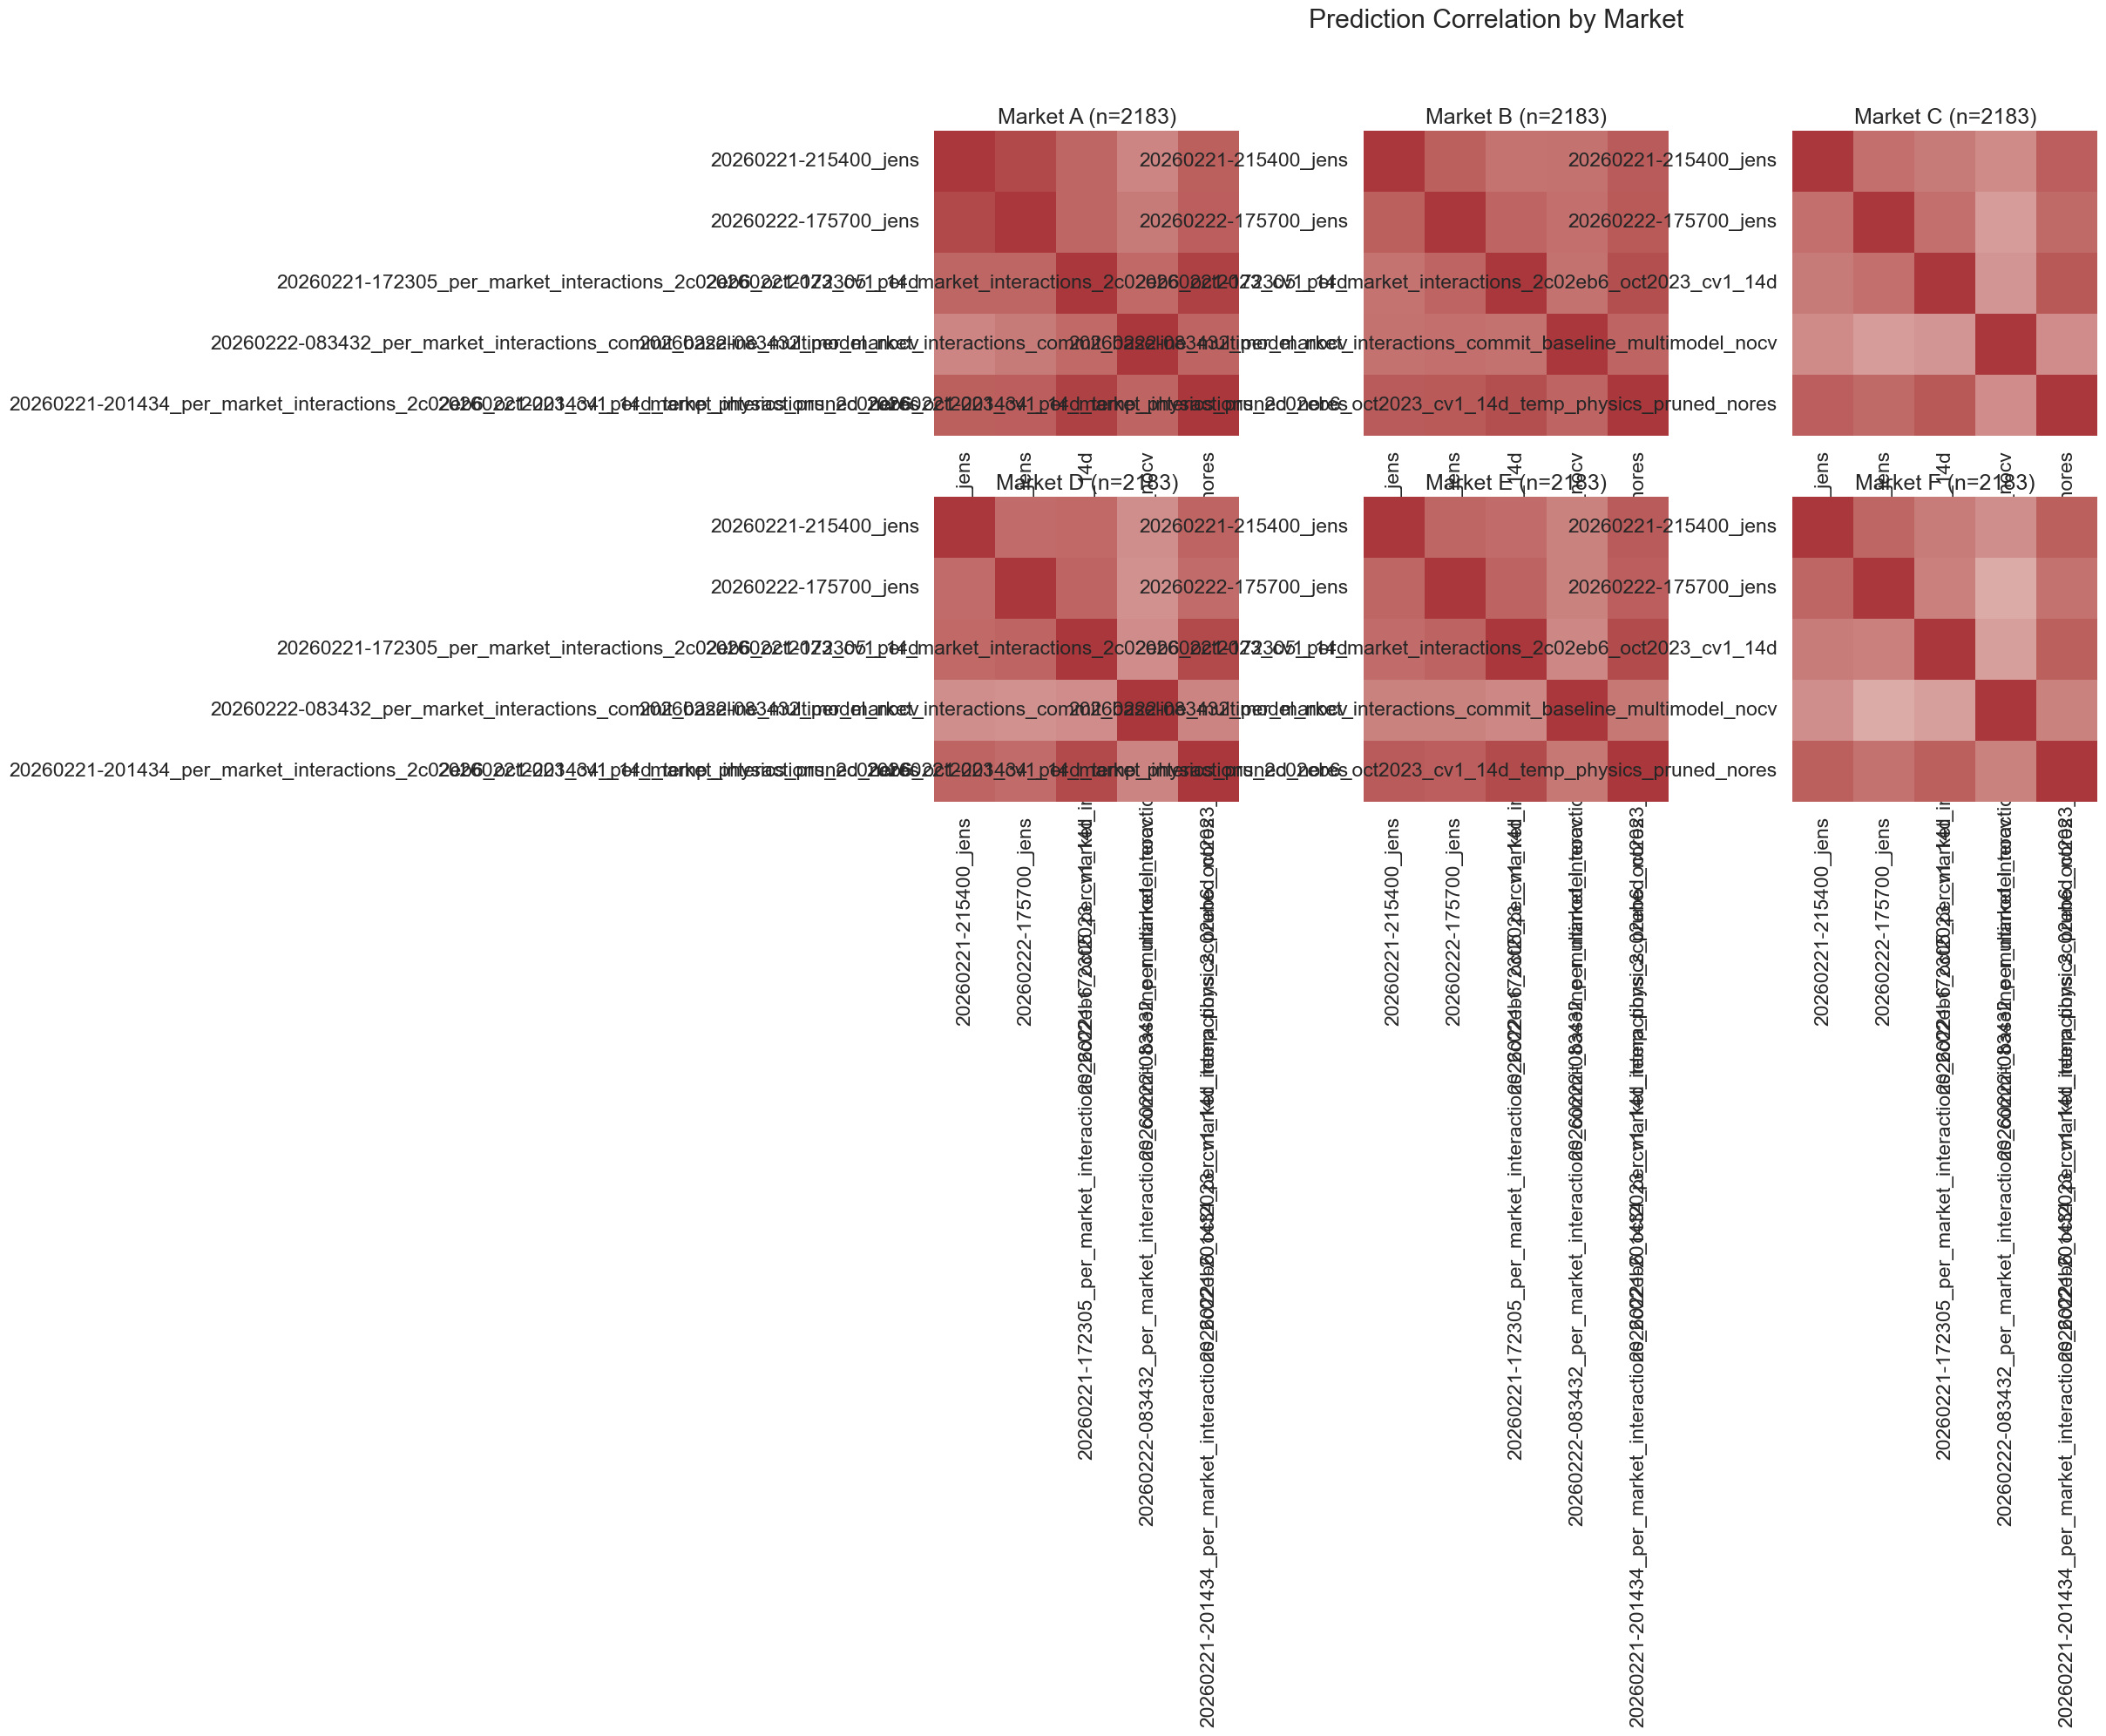

In [13]:
# Correlation heatmap per market
markets = sorted(model_df["market"].dropna().unique())
if not markets:
    raise RuntimeError("No market values found in metadata.")

n = len(markets)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows), squeeze=False)

for i, market in enumerate(markets):
    ax = axes[i // cols][i % cols]
    sub = model_df.loc[model_df["market"] == market, submission_cols]
    corr = sub.corr()
    sns.heatmap(corr, cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax, cbar=False)
    ax.set_title(f"{market} (n={len(sub)})")

for j in range(i + 1, rows * cols):
    axes[j // cols][j % cols].axis("off")

plt.suptitle("Prediction Correlation by Market", y=1.02)
plt.tight_layout()
plt.show()


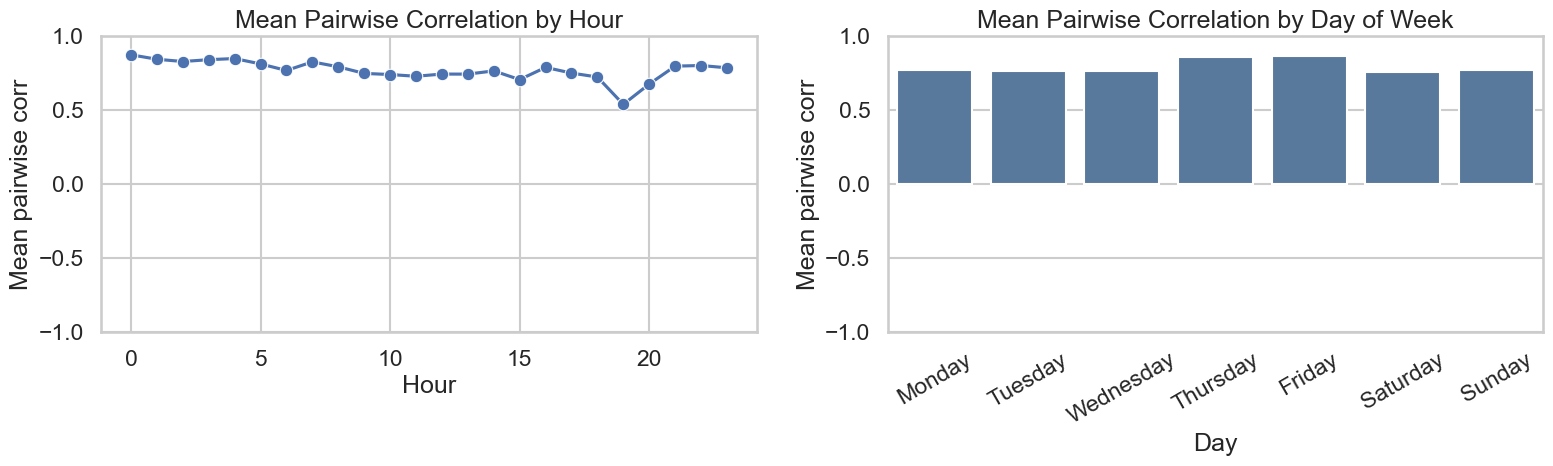

In [14]:
def pairwise_corr_by_group(df: pd.DataFrame, group_col: str, cols: list[str]) -> pd.DataFrame:
    pairs = list(combinations(cols, 2))
    rows = []
    for group_val, g in df.groupby(group_col, sort=True):
        for a, b in pairs:
            x = g[a].to_numpy()
            y = g[b].to_numpy()
            if len(g) < 3:
                corr = np.nan
            else:
                corr = np.corrcoef(x, y)[0, 1]
            rows.append({"group": group_val, "a": a, "b": b, "corr": corr, "n": len(g)})
    return pd.DataFrame(rows)


hour_pair = pairwise_corr_by_group(model_df, "hour", submission_cols)
dow_pair = pairwise_corr_by_group(model_df, "dow_name", submission_cols)

hour_summary = hour_pair.groupby("group", as_index=False)["corr"].mean().sort_values("group")
dow_summary = dow_pair.groupby("group", as_index=False)["corr"].mean()
if "dow_name" in model_df.columns:
    ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_summary["group"] = pd.Categorical(dow_summary["group"], categories=ordered_days, ordered=True)
    dow_summary = dow_summary.sort_values("group")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=hour_summary, x="group", y="corr", marker="o", ax=axes[0])
axes[0].set_title("Mean Pairwise Correlation by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean pairwise corr")
axes[0].set_ylim(-1, 1)

sns.barplot(data=dow_summary, x="group", y="corr", ax=axes[1], color="#4C78A8")
axes[1].set_title("Mean Pairwise Correlation by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Mean pairwise corr")
axes[1].set_ylim(-1, 1)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Reference submission: 20260221-215400_jens


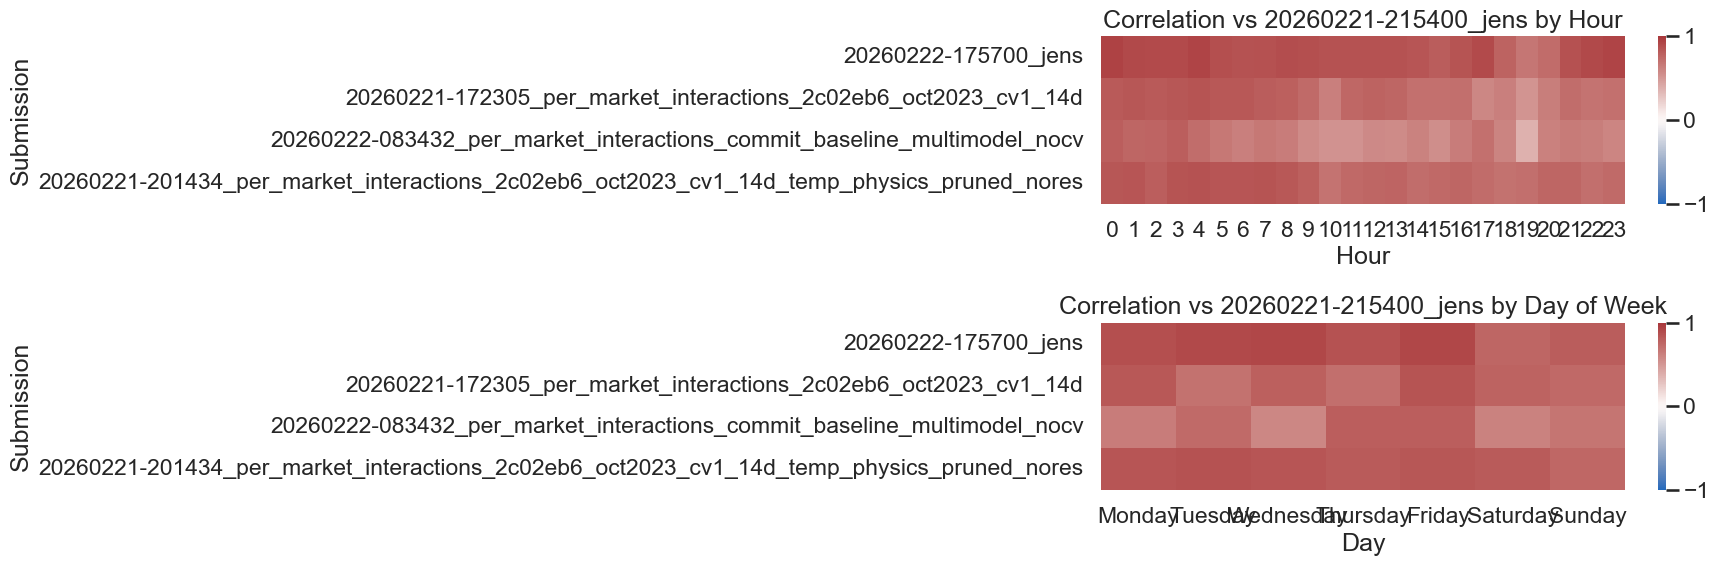

In [15]:
# Correlation to a reference submission by hour and day-of-week
reference_label = REFERENCE_LABEL if REFERENCE_LABEL in submission_cols else submission_cols[0]
others = [c for c in submission_cols if c != reference_label]
print("Reference submission:", reference_label)

if not others:
    print("Only one submission available; need at least two for pairwise analysis.")
else:
    hours = list(range(24))
    hour_ref = pd.DataFrame(index=others, columns=hours, dtype=float)
    for h in hours:
        g = model_df.loc[model_df["hour"] == h]
        for col in others:
            if len(g) >= 3:
                hour_ref.loc[col, h] = np.corrcoef(g[reference_label], g[col])[0, 1]

    dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_ref = pd.DataFrame(index=others, columns=dow_order, dtype=float)
    for d in dow_order:
        g = model_df.loc[model_df["dow_name"] == d]
        for col in others:
            if len(g) >= 3:
                dow_ref.loc[col, d] = np.corrcoef(g[reference_label], g[col])[0, 1]

    fig, axes = plt.subplots(2, 1, figsize=(18, max(6, 0.35 * len(others) + 4)))
    sns.heatmap(hour_ref, cmap="vlag", vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title(f"Correlation vs {reference_label} by Hour")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Submission")

    sns.heatmap(dow_ref, cmap="vlag", vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title(f"Correlation vs {reference_label} by Day of Week")
    axes[1].set_xlabel("Day")
    axes[1].set_ylabel("Submission")

    plt.tight_layout()
    plt.show()


In [16]:
# Quick table: lowest-correlation pairs overall
pairs = []
for a, b in combinations(submission_cols, 2):
    c = model_df[[a, b]].corr().iloc[0, 1]
    pairs.append((a, b, c))

pair_df = pd.DataFrame(pairs, columns=["submission_a", "submission_b", "corr"]).sort_values("corr")
display(pair_df.head(20))


,submission_a,submission_b,corr
2,20260221-215400_jens,20260222-083432_per_market_interactions_commit...,0.608990
5,20260222-175700_jens,20260222-083432_per_market_interactions_commit...,0.611123
7,20260221-172305_per_market_interactions_2c02eb...,20260222-083432_per_market_interactions_commit...,0.652703
9,20260222-083432_per_market_interactions_commit...,20260221-201434_per_market_interactions_2c02eb...,0.705442
1,20260221-215400_jens,20260221-172305_per_market_interactions_2c02eb...,0.741606
4,20260222-175700_jens,20260221-172305_per_market_interactions_2c02eb...,0.765107
6,20260222-175700_jens,20260221-201434_per_market_interactions_2c02eb...,0.798319
3,20260221-215400_jens,20260221-201434_per_market_interactions_2c02eb...,0.813522
0,20260221-215400_jens,20260222-175700_jens,0.840213
8,20260221-172305_per_market_interactions_2c02eb...,20260221-201434_per_market_interactions_2c02eb...,0.909322
